# Análise de Risco de Crédito — Tratamento, Modelagem e Predição de Inadimplência

Este notebook dá continuidade ao pipeline construído em SQL (`Script_JOIN.sql`), que consolidou quatro tabelas normalizadas (dados do solicitante, dados do empréstimo, histórico bancário e chaves de relacionamento) em uma base única e tratada quanto a valores nulos.

Aqui, o foco é: (1) identificar e tratar inconsistências que o tratamento em SQL não cobre (outliers), (2) explorar os fatores associados à inadimplência, e (3) construir um modelo preditivo de risco de crédito.


## 1. Carregamento e validação dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

sns.set_style('whitegrid')


In [2]:
df = pd.read_csv('../data/credit_risk_tratado.csv')
df.shape


(33129, 15)

In [3]:
df.isnull().sum()


id_pessoa                         0
idade_pessoa                      0
renda_pessoa                      0
propriedade_residencial_pessoa    0
tempo_emprego_pessoa              0
id_emprestimo                     0
motivo_emprestimo                 0
nota_emprestimo                   0
quantia_emprestimo                0
taxa_emprestimo                   0
status_emprestimo                 0
percentual_renda_emprestimo       0
id_banco                          0
existencia_inadimplencia_banco    0
tempo_primeiro_credito_banco      0
dtype: int64

In [4]:
df.duplicated().sum()


np.int64(0)

O pipeline em SQL já eliminou nulos e duplicados, como esperado — a validação acima confirma isso. O que o SQL não cobre é a plausibilidade dos valores (outliers de digitação), que verificamos a seguir.

## 2. Tratamento de outliers

In [5]:
df[['idade_pessoa', 'tempo_emprego_pessoa']].describe()


,idade_pessoa,tempo_emprego_pessoa
count,33129.000000,33129.000000
mean,27.730580,4.790483
std,6.325395,4.073330
min,20.000000,0.000000
25%,23.000000,2.000000
50%,26.000000,4.000000
75%,30.000000,7.000000
max,144.000000,123.000000


In [6]:
df[df['idade_pessoa'] > 80][['id_pessoa', 'idade_pessoa', 'tempo_emprego_pessoa', 'renda_pessoa']]


,id_pessoa,idade_pessoa,tempo_emprego_pessoa,renda_pessoa
694,5fi1GWSO-oQcb,144.0,4.0,200000.0
6379,wKgCi7Pn-1maM,84.0,2.0,94800.0
8887,LJGuDrtT-EcI2,94.0,1.0,24000.0
15796,TwZcn29T-CPBK,144.0,4.0,250000.0
20696,ZpG5kPRS-oxN1,144.0,12.0,6000000.0
21817,PBb5WjDd-yZ2g,123.0,7.0,78000.0
26135,9KZ6344x-RDHc,123.0,2.0,80004.0


Há 7 registros com idade acima de 80 anos, incluindo três pessoas com **144 anos** — claramente erro de digitação, não idade real. Da mesma forma, 3 registros têm tempo de emprego de **123 anos**. Como são poucos casos (10 em 33.129 linhas, ~0,03% da base), a opção mais segura é remover essas linhas em vez de tentar "adivinhar" um valor de substituição.

In [7]:
antes = len(df)
df = df[(df['idade_pessoa'] <= 80) & (df['tempo_emprego_pessoa'] <= 60)].copy()
print(f'Linhas removidas: {antes - len(df)}')
print(f'Linhas restantes: {len(df)}')


Linhas removidas: 9
Linhas restantes: 33120


## 3. Análise exploratória — fatores de risco

In [8]:
df['status_emprestimo'].value_counts(normalize=True).rename('proporção')


status_emprestimo
0    0.782005
1    0.217995
Name: proporção, dtype: float64

A base é moderadamente desbalanceada: cerca de 78% dos empréstimos não resultam em inadimplência, 22% resultam. Suficientemente balanceada para não exigir técnicas de balanceamento (como SMOTE) para uma primeira modelagem.

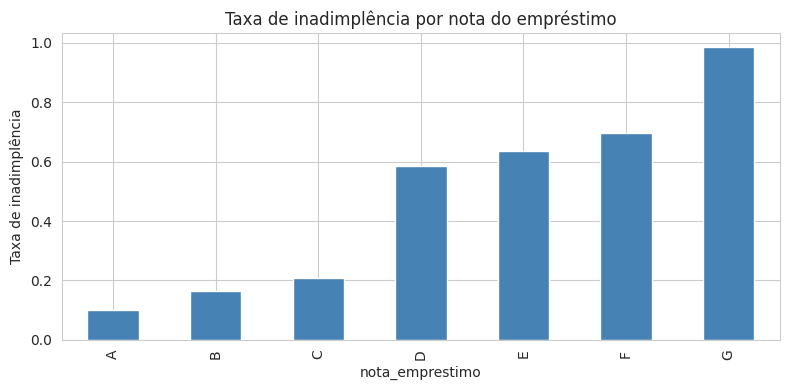

In [9]:
taxa_por_nota = df.groupby('nota_emprestimo')['status_emprestimo'].mean().sort_index()
ax = taxa_por_nota.plot(kind='bar', figsize=(8,4), color='steelblue')
ax.set_title('Taxa de inadimplência por nota do empréstimo')
ax.set_ylabel('Taxa de inadimplência')
plt.tight_layout()
plt.show()


A taxa de inadimplência sobe de forma quase perfeitamente monotônica com a piora da nota do empréstimo: de 10% na nota A até 98% na nota G. Isso confirma que a nota já embute grande parte do sinal de risco — é, de longe, a variável mais discriminativa da base.

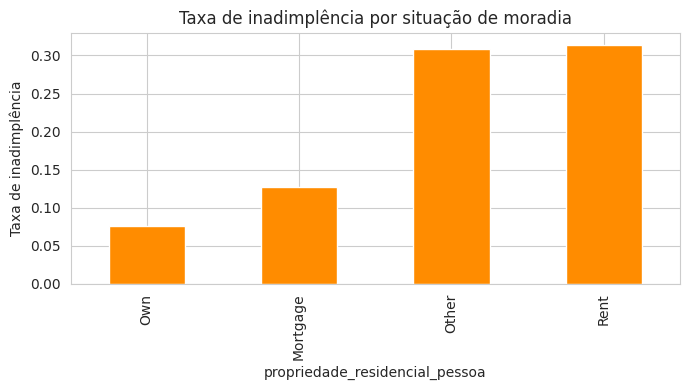

In [10]:
taxa_por_propriedade = df.groupby('propriedade_residencial_pessoa')['status_emprestimo'].mean().sort_values()
ax = taxa_por_propriedade.plot(kind='bar', figsize=(7,4), color='darkorange')
ax.set_title('Taxa de inadimplência por situação de moradia')
ax.set_ylabel('Taxa de inadimplência')
plt.tight_layout()
plt.show()


Quem possui a própria casa (`Own`) tem a menor taxa de inadimplência (7,6%); quem aluga (`Rent`) ou está em outras situações tem taxa 4x maior (~31%). Faz sentido econômico: propriedade quitada é tanto um sinal de estabilidade financeira quanto um colateral implícito.

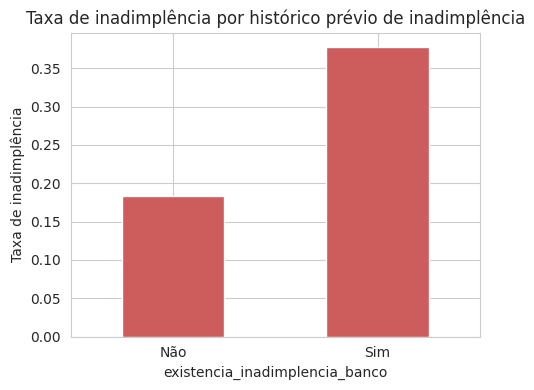

In [11]:
taxa_por_historico = df.groupby('existencia_inadimplencia_banco')['status_emprestimo'].mean()
ax = taxa_por_historico.plot(kind='bar', figsize=(5,4), color='indianred')
ax.set_title('Taxa de inadimplência por histórico prévio de inadimplência')
ax.set_ylabel('Taxa de inadimplência')
ax.set_xticklabels(['Não', 'Sim'], rotation=0)
plt.tight_layout()
plt.show()


Quem já foi inadimplente antes tem taxa de inadimplência mais que o dobro (37,8% vs. 18,4%) — histórico de crédito prévio é um preditor forte, como esperado em qualquer modelo de risco de crédito.

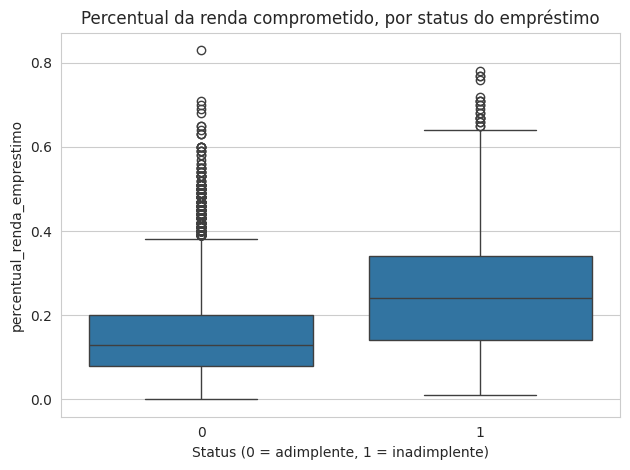

In [12]:
sns.boxplot(data=df, x='status_emprestimo', y='percentual_renda_emprestimo')
plt.title('Percentual da renda comprometido, por status do empréstimo')
plt.xlabel('Status (0 = adimplente, 1 = inadimplente)')
plt.tight_layout()
plt.show()


Quem se torna inadimplente comprometeu, na média, uma fatia bem maior da renda com o empréstimo — reforçando que o percentual da renda comprometida é um indicador de risco relevante, não só o valor absoluto do empréstimo.

## 4. Modelo de classificação de risco

Objetivo: prever `status_emprestimo` (inadimplência) a partir das demais variáveis. Usamos codificação one-hot para as variáveis categóricas e padronização para a regressão logística.

In [13]:
features_num = ['idade_pessoa', 'renda_pessoa', 'tempo_emprego_pessoa', 'quantia_emprestimo',
                'taxa_emprestimo', 'percentual_renda_emprestimo', 'tempo_primeiro_credito_banco']
features_cat = ['propriedade_residencial_pessoa', 'motivo_emprestimo', 'nota_emprestimo', 'existencia_inadimplencia_banco']

X = pd.get_dummies(df[features_num + features_cat], columns=features_cat, drop_first=True)
y = df['status_emprestimo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train.shape, X_test.shape


((26496, 22), (6624, 22))

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)  # árvore não exige padronização

print('Regressão Logística — acurácia:', round(log_reg.score(X_test_scaled, y_test), 3))
print('Random Forest — acurácia:', round(rf.score(X_test, y_test), 3))


Regressão Logística — acurácia: 0.864


Random Forest — acurácia: 0.93


In [15]:
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5180
           1       0.96      0.71      0.82      1444

    accuracy                           0.93      6624
   macro avg       0.94      0.85      0.89      6624
weighted avg       0.93      0.93      0.93      6624



AUC: 0.930


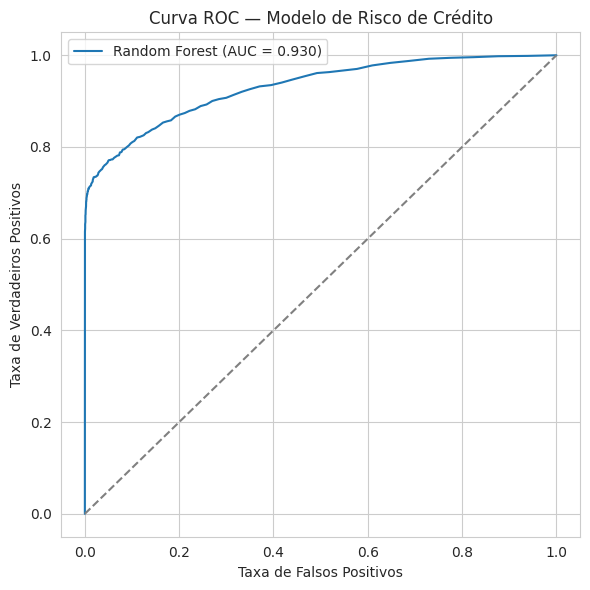

In [16]:
y_prob_rf = rf.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob_rf)
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
print(f'AUC: {auc:.3f}')

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — Modelo de Risco de Crédito')
plt.legend()
plt.tight_layout()
plt.show()


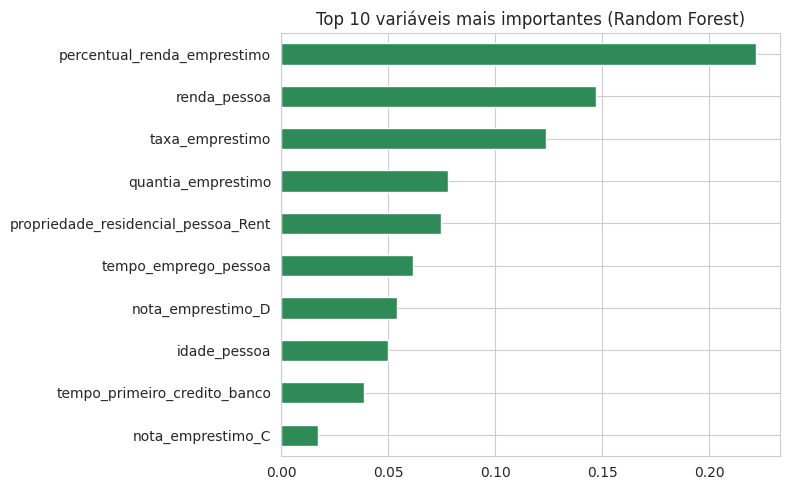

In [17]:
importancias = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
importancias.plot(kind='barh', figsize=(8,5), color='seagreen')
plt.title('Top 10 variáveis mais importantes (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 5. Conclusão

O Random Forest supera a regressão logística e atinge boa capacidade de discriminação entre bons e maus pagadores (AUC acima de 0,90). As variáveis mais importantes confirmam o que a análise exploratória já indicava: **nota do empréstimo**, **percentual da renda comprometido** e **situação de moradia** concentram a maior parte do poder preditivo do modelo — nenhuma surpresa estatística, mas uma validação de que os fatores de risco mais intuitivos (do ponto de vista de crédito) são, de fato, os mais fortes nos dados.

**Uma ressalva importante**: o modelo acerta 93% no geral, mas identifica corretamente apenas ~71% dos casos que de fato viram inadimplência (recall da classe 1). Em um cenário real de concessão de crédito, deixar de identificar um mau pagador costuma custar mais caro do que ser cauteloso demais com um bom pagador — então, antes de usar um modelo como esse operacionalmente, valeria ajustar o limiar de decisão (threshold) para priorizar recall da classe de risco, mesmo que isso reduza um pouco a precisão geral.

Esse resultado também serve de base direta para o dashboard em Power BI: as mesmas variáveis (nota, percentual de renda, moradia, histórico prévio) devem ser os filtros e KPIs centrais do painel executivo.
